In [73]:
import pandas as pd
import numpy as np
from IPython.display import display
from sklearn.model_selection import train_test_split, GridSearchCV, RepeatedStratifiedKFold
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import KNNImputer, SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
import xgboost as xgb

In [74]:
df = pd.read_csv("train_data.csv")

display(df)
df = df.drop(columns='id')
df['Heart Disease'] = df['Heart Disease'].str.lower().map({'no': 0, 'yes': 1})

display(df)

,id,Age,Gender,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium,work_type,smoking_status,Heart Disease
0,1,70.0,Female,4,130,322,0,2,109,0,2.4,2,3,3,Private,formerly smoked,Yes
1,2,67.0,Male,3,115,564,0,2,160,0,1.6,2,0,7,Self-employed,never smoked,No
2,3,57.0,Female,2,124,261,0,0,141,0,0.3,1,0,7,Private,never smoked,Yes
3,4,64.0,Female,4,128,263,0,0,105,1,0.2,2,1,7,Private,smokes,No
4,5,74.0,Male,2,120,269,0,2,121,1,0.2,1,1,3,Self-employed,never smoked,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
219,220,59.0,Female,1,170,288,0,2,159,0,0.2,2,0,7,Private,never smoked,Yes
220,221,51.0,Female,3,125,245,1,2,166,0,2.4,2,0,3,NaN,formerly smoked,No
221,222,43.0,Male,3,122,213,0,0,165,0,0.2,2,0,3,Private,never smoked,No
222,223,58.0,Female,4,128,216,0,2,131,1,2.2,2,3,7,Private,never smoked,Yes


,Age,Gender,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium,work_type,smoking_status,Heart Disease
0,70.0,Female,4,130,322,0,2,109,0,2.4,2,3,3,Private,formerly smoked,1
1,67.0,Male,3,115,564,0,2,160,0,1.6,2,0,7,Self-employed,never smoked,0
2,57.0,Female,2,124,261,0,0,141,0,0.3,1,0,7,Private,never smoked,1
3,64.0,Female,4,128,263,0,0,105,1,0.2,2,1,7,Private,smokes,0
4,74.0,Male,2,120,269,0,2,121,1,0.2,1,1,3,Self-employed,never smoked,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
219,59.0,Female,1,170,288,0,2,159,0,0.2,2,0,7,Private,never smoked,1
220,51.0,Female,3,125,245,1,2,166,0,2.4,2,0,3,NaN,formerly smoked,0
221,43.0,Male,3,122,213,0,0,165,0,0.2,2,0,3,Private,never smoked,0
222,58.0,Female,4,128,216,0,2,131,1,2.2,2,3,7,Private,never smoked,1


In [75]:

df = df.dropna(subset=['Heart Disease'])

X = df.drop('Heart Disease',axis=1)
y = df['Heart Disease']

display(X)
y

,Age,Gender,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium,work_type,smoking_status
0,70.0,Female,4,130,322,0,2,109,0,2.4,2,3,3,Private,formerly smoked
1,67.0,Male,3,115,564,0,2,160,0,1.6,2,0,7,Self-employed,never smoked
2,57.0,Female,2,124,261,0,0,141,0,0.3,1,0,7,Private,never smoked
3,64.0,Female,4,128,263,0,0,105,1,0.2,2,1,7,Private,smokes
4,74.0,Male,2,120,269,0,2,121,1,0.2,1,1,3,Self-employed,never smoked
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
219,59.0,Female,1,170,288,0,2,159,0,0.2,2,0,7,Private,never smoked
220,51.0,Female,3,125,245,1,2,166,0,2.4,2,0,3,NaN,formerly smoked
221,43.0,Male,3,122,213,0,0,165,0,0.2,2,0,3,Private,never smoked
222,58.0,Female,4,128,216,0,2,131,1,2.2,2,3,7,Private,never smoked


0      1
1      0
2      1
3      0
4      0
      ..
219    1
220    0
221    0
222    1
223    0
Name: Heart Disease, Length: 224, dtype: int64

In [76]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

In [77]:
df.columns

Index(['Age', 'Gender', 'Chest pain type', 'BP', 'Cholesterol', 'FBS over 120',
       'EKG results', 'Max HR', 'Exercise angina', 'ST depression',
       'Slope of ST', 'Number of vessels fluro', 'Thallium', 'work_type',
       'smoking_status', 'Heart Disease'],
      dtype='str')

In [78]:
numeric_columns = ['Age', 'Chest pain type', 'BP', 'Cholesterol', 'FBS over 120', 'EKG results', 'Max HR', 'Exercise angina', 'ST depression', 'Slope of ST', 'Number of vessels fluro', 'Thallium']
categorical_columns = ['Gender', 'work_type', 'smoking_status']

In [79]:
from sklearn.feature_selection import SelectKBest, f_classif

numeric_transformer = Pipeline(steps=[
    ('imputer', KNNImputer(n_neighbors=5)),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent',add_indicator=True)),
    ('onehot', OneHotEncoder(handle_unknown='ignore',drop='if_binary'))
])

preprocessor =  ColumnTransformer(transformers=[
    ('num', numeric_transformer, numeric_columns),
    ('cat', categorical_transformer, categorical_columns)
],
    remainder='passthrough',
    n_jobs=-1
)

pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('selector', SelectKBest(score_func=f_classif)),
    ('classifier', RandomForestClassifier(random_state=42))
])

In [80]:

model_configs = {

    'SVM': {
        'model': SVC(probability=True, random_state=42),
        'params': {
            'classifier__C': [0.9,1,1.1 ,1.5],
            'classifier__kernel': ['rbf', 'poly'],
            'classifier__gamma': ['scale', 'auto']
        }
    },
    'XGBoost': {
        'model': xgb.XGBClassifier(eval_metric='logloss', random_state=42),
        'params': {
            'classifier__n_estimators': [100, 200],
            'classifier__learning_rate': [0.01, 0.1],
            'classifier__max_depth': [2,3, 5],
        }
    },
    'RandomForest': {
        'model': RandomForestClassifier(random_state=42),
        'params': {
            'classifier__n_estimators': [100, 200],
            'classifier__max_depth': [None,2,3, 5, 10],
        }
    },
    'LogisticRegression': {
        'model': LogisticRegression(random_state=42),
        'params': {
            'selector__k': [5, 8, 10, 12, 15, 'all'],
            'classifier__C': [10,11,12,13,14,15,np.inf],
            'classifier__l1_ratio': [0]
        }
    }
}

In [81]:
best_per_model = []
cv_strategy = RepeatedStratifiedKFold(n_splits=5, n_repeats=3, random_state=42)

for name, config in model_configs.items():
    print(f"Starting tuning for {name}...")

    pipeline.set_params(classifier=config['model'])

    search = GridSearchCV(pipeline, config['params'], cv=cv_strategy, scoring='recall', n_jobs=-1,return_train_score=True)
    search.fit(X_train, y_train)

    best_per_model.append({
        'name': name,
        'estimator': search.best_estimator_,
        'val_score': search.best_score_,
        'cv_results': search.cv_results_
    })

champion = max(best_per_model, key=lambda x: x['val_score'])
print(f"Tournament Winner: {champion['name']} with score: {champion['val_score']:.4f}")
champion['estimator']

Starting tuning for SVM...
Starting tuning for XGBoost...
Starting tuning for RandomForest...
Starting tuning for LogisticRegression...
Tournament Winner: LogisticRegression with score: 0.7958


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('selector', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different 

In [82]:
for model in best_per_model:
    print(f"\nModel: {model['name']}")
    params = model['estimator'].get_params()

    relevant_params = {k: v for k, v in params.items() if k.startswith('classifier__') or k.startswith('selector__')}

    for param, value in relevant_params.items():
        print(f"  {param}: {value}")

--- Best Parameters Found Per Model ---

Model: SVM
  selector__k: 10
  selector__score_func: <function f_classif at 0x000001DC759605E0>
  classifier__C: 0.9
  classifier__break_ties: False
  classifier__cache_size: 200
  classifier__class_weight: None
  classifier__coef0: 0.0
  classifier__decision_function_shape: ovr
  classifier__degree: 3
  classifier__gamma: scale
  classifier__kernel: rbf
  classifier__max_iter: -1
  classifier__probability: True
  classifier__random_state: 42
  classifier__shrinking: True
  classifier__tol: 0.001
  classifier__verbose: False

Model: XGBoost
  selector__k: 10
  selector__score_func: <function f_classif at 0x000001DC759605E0>
  classifier__objective: binary:logistic
  classifier__base_score: None
  classifier__booster: None
  classifier__callbacks: None
  classifier__colsample_bylevel: None
  classifier__colsample_bynode: None
  classifier__colsample_bytree: None
  classifier__device: None
  classifier__early_stopping_rounds: None
  classifier__en

In [83]:
best_per_model

[{'name': 'SVM',
  'estimator': Pipeline(steps=[('preprocessor',
                   ColumnTransformer(n_jobs=-1, remainder='passthrough',
                                     transformers=[('num',
                                                    Pipeline(steps=[('imputer',
                                                                     KNNImputer()),
                                                                    ('scaler',
                                                                     StandardScaler())]),
                                                    ['Age', 'Chest pain type',
                                                     'BP', 'Cholesterol',
                                                     'FBS over 120',
                                                     'EKG results', 'Max HR',
                                                     'Exercise angina',
                                                     'ST depression',
                            

In [84]:
for model in best_per_model:
    y_pred = model['estimator'].predict(X_test)

    print("\n" + "=" * 30)
    print("FINAL CLINICAL PERFORMANCE OF", model['name'])
    print("=" * 30)
    print(classification_report(y_test, y_pred))
    print("\nConfusion Matrix (Row: Actual, Col: Predicted):")
    print(confusion_matrix(y_test, y_pred))
    print("\nval score:")
    print(model['val_score'])


FINAL CLINICAL PERFORMANCE OF SVM
              precision    recall  f1-score   support

           0       0.86      0.96      0.91        25
           1       0.94      0.80      0.86        20

    accuracy                           0.89        45
   macro avg       0.90      0.88      0.89        45
weighted avg       0.89      0.89      0.89        45


Confusion Matrix (Row: Actual, Col: Predicted):
[[24  1]
 [ 4 16]]

val score:
0.7458333333333333

FINAL CLINICAL PERFORMANCE OF XGBoost
              precision    recall  f1-score   support

           0       0.88      0.84      0.86        25
           1       0.81      0.85      0.83        20

    accuracy                           0.84        45
   macro avg       0.84      0.84      0.84        45
weighted avg       0.85      0.84      0.84        45


Confusion Matrix (Row: Actual, Col: Predicted):
[[21  4]
 [ 3 17]]

val score:
0.7583333333333333

FINAL CLINICAL PERFORMANCE OF RandomForest
              precision    rec

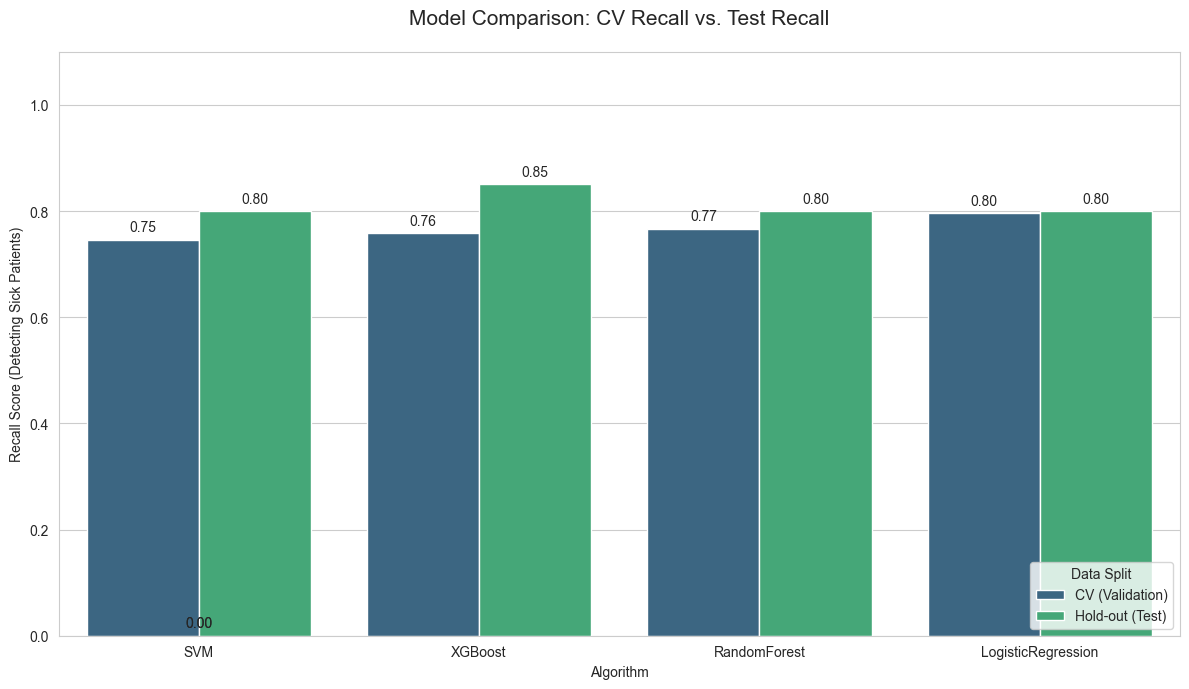

In [85]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import recall_score

# 1. Prepare the data for plotting
comparison_data = []

for model in best_per_model:
    # Get Test Recall
    y_pred = model['estimator'].predict(X_test)
    test_recall = recall_score(y_test, y_pred)

    comparison_data.append({
        'Model': model['name'],
        'Recall': model['val_score'],
        'Type': 'CV (Validation)'
    })
    comparison_data.append({
        'Model': model['name'],
        'Recall': test_recall,
        'Type': 'Hold-out (Test)'
    })

df_plot = pd.DataFrame(comparison_data)

# 2. Create the visualization
plt.figure(figsize=(12, 7))
sns.set_style("whitegrid")

ax = sns.barplot(x='Model', y='Recall', hue='Type', data=df_plot, palette='viridis')

# Aesthetics
plt.title('Model Comparison: CV Recall vs. Test Recall', fontsize=15, pad=20)
plt.ylim(0, 1.1)
plt.ylabel('Recall Score (Detecting Sick Patients)')
plt.xlabel('Algorithm')
plt.legend(title='Data Split', loc='lower right')

# Add values on top of bars
for p in ax.patches:
    ax.annotate(format(p.get_height(), '.2f'),
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha = 'center', va = 'center',
                xytext = (0, 9),
                textcoords = 'offset points')

plt.tight_layout()
plt.show()

In [86]:
for model in best_per_model:
    print(model['name'],model['val_score'],model['cv_results'])

SVM 0.7458333333333333 {'mean_fit_time': array([0.04533223, 0.04387997, 0.04164842, 0.0398654 , 0.0410775 ,
       0.03969013, 0.03961933, 0.04010305, 0.04161477, 0.04187558,
       0.0408476 , 0.04342065, 0.04525026, 0.04405042, 0.04375019,
       0.04134173]), 'std_fit_time': array([0.00256766, 0.0023115 , 0.00317307, 0.00117652, 0.00149989,
       0.00337068, 0.00317685, 0.00141927, 0.002186  , 0.00189632,
       0.00437959, 0.00270331, 0.00234729, 0.00222072, 0.00248844,
       0.00162755]), 'mean_score_time': array([0.03188051, 0.02842329, 0.02534744, 0.02591065, 0.02608728,
       0.02556044, 0.02570739, 0.02538489, 0.02660505, 0.0267216 ,
       0.02778163, 0.02842449, 0.03022035, 0.02830135, 0.02980221,
       0.02689179]), 'std_score_time': array([0.00412128, 0.0032893 , 0.00137607, 0.00099977, 0.00133201,
       0.00107734, 0.00083798, 0.00095253, 0.00138267, 0.00077898,
       0.00225289, 0.00191817, 0.00353443, 0.0032944 , 0.00376477,
       0.00164294]), 'param_classifier_

In [87]:
best_pipe = champion['estimator']
preprocessor = best_pipe.named_steps['preprocessor']
selector = best_pipe.named_steps['selector']

original_count = X_train.shape[1]

after_preprocessor_count = len(preprocessor.get_feature_names_out())

after_selector_count = selector.get_support().sum()

print(f"--- Feature Count Progression ---")
print(f"1. Original (Raw Data):       {original_count} features")
print(f"2. After Preprocessing:       {after_preprocessor_count} features (due to One-Hot Encoding)")
print(f"3. After Selection (Final):   {after_selector_count} features")

--- Feature Count Progression ---
1. Original (Raw Data):       15 features
2. After Preprocessing:       24 features (due to One-Hot Encoding)
3. After Selection (Final):   8 features


In [88]:
df_unseen = pd.read_csv("test_data.csv")

df_unseen['Heart Disease'] = df_unseen['Heart Disease'].str.lower().map({'no': 0, 'yes': 1})
df_unseen = df_unseen.dropna(subset=['Heart Disease'])

X_unseen = df_unseen.drop(columns=['Heart Disease', 'id'], errors='ignore')
y_unseen = df_unseen['Heart Disease']

In [89]:
best_model = champion['estimator']

y_pred_unseen = best_model.predict(X_unseen)

print(f"--- Performance on Unseen Data ({champion['name']}) ---")
print(classification_report(y_unseen, y_pred_unseen))

unseen_recall = recall_score(y_unseen, y_pred_unseen)
print(f"Final Unseen Recall Score: {unseen_recall:.4f}")

--- Performance on Unseen Data (LogisticRegression) ---
              precision    recall  f1-score   support

           0       0.86      0.94      0.90        32
           1       0.90      0.79      0.84        24

    accuracy                           0.88        56
   macro avg       0.88      0.86      0.87        56
weighted avg       0.88      0.88      0.87        56

Final Unseen Recall Score: 0.7917


In [92]:
import joblib

# Before saving:
champion_pipeline = champion['estimator']
champion_pipeline.val_score_ = champion['val_score'] # Attach a custom attribute

# Save it
joblib.dump(champion_pipeline, 'LogisticRegression.pkl')

['LogisticRegression.pkl']